To implement decoder model architecture, we will need to accomplish following tasks:

1) Text needs to be converted into tokens

2) For step 1, we will need to implement a tokenizer

3) For step 2, we will create a character based tokenizer and train it on data corpus

4) tokenizer should be able to convert text into numbers(encode) and convert numbers back to characters(decode)

5) tokenizer will have its own vocab and dictionaries to perform forward and reverse lookups

6) We will need a dataset which will be converted into iterator and dataloader be created after it. 
Dataloader should create inputs and labels such that labels are 1 position behind the input(DataCollator for Language Modeling in hugging face).

7) We need to create decoder model now

8) First step is to create embedding layer whose input size is equal to vocabulary size and output size is equal to number of dimensions we want to create for each input.

9) Second step is to create positional embeddings whose input size is equal to context length and output isze is equal to model dimension(same as in step 8)

10) add 8+9 and then feed it to decoder block
                                                                                                                                                          
11) Continue with decoder block tomorrow

12) Decoder --> layer norm --> Attention head --> concat attention heads--> add linear layer--> feed forward layer - squeeze and excite with gelu in between (add dropout and layer norm as required)

13) Create decoder layers

14) Finally put linear layer which converts model dimension to vocab dimension for each position

15) train the model ...<<<more to follow tomorrow>>>

## Let us implement character tokenizer

Steps in implementing chracter tokenizer:
1) Reading the text and creating a vocabulary
2) Mapping vocab tokens to ids and then from ids to vocab tokens
3) Encode function that takes text; convert it into tokens and then into token ids
4) Decode function that takes tokenids, converts into tokens and then joins tokens to form a coherent text

In [1]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
from pathlib import Path
import sys
from torch.utils.data import Dataset, DataLoader, RandomSampler

/home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cpu


In [4]:
try:
    from transformers import AutoTokenizer, AutoModelForCausalLM
    from datasets import load_dataset
except:
    print("datasets/transformers package is not installed. installing it now. Please remember to start kernel once installation is complete")
    !pip install transformers
    !pip install datasets==3.3.2
    print("Please restart your kernel now")

In [5]:
ckpt = "openai-community/gpt2"

In [5]:
model = AutoModelForCausalLM.from_pretrained(ckpt)
total_params = sum([p.numel() for p in model.parameters()])
total_params/(1024**2), model

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

(118.675048828125,
 GPT2LMHeadModel(
   (transformer): GPT2Model(
     (wte): Embedding(50257, 768)
     (wpe): Embedding(1024, 768)
     (drop): Dropout(p=0.1, inplace=False)
     (h): ModuleList(
       (0-11): 12 x GPT2Block(
         (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
         (attn): GPT2Attention(
           (c_attn): Conv1D(nf=2304, nx=768)
           (c_proj): Conv1D(nf=768, nx=768)
           (attn_dropout): Dropout(p=0.1, inplace=False)
           (resid_dropout): Dropout(p=0.1, inplace=False)
         )
         (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
         (mlp): GPT2MLP(
           (c_fc): Conv1D(nf=3072, nx=768)
           (c_proj): Conv1D(nf=768, nx=3072)
           (act): NewGELUActivation()
           (dropout): Dropout(p=0.1, inplace=False)
         )
       )
     )
     (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
   )
   (lm_head): Linear(in_features=768, out_features=50257, bias=False)
 ))

In [6]:
ds = load_dataset("Trelis/tiny-shakespeare")

In [7]:
ds

DatasetDict({
    train: Dataset({
        features: ['Text'],
        num_rows: 472
    })
    test: Dataset({
        features: ['Text'],
        num_rows: 49
    })
})

In [8]:
len(ds['train'][0]['Text'])

3131

In [9]:
len_train = len(ds['train'])

In [10]:
for i in range(len_train):
    print(len(ds['train'][i]['Text']))

3131
1703
1614
3199
3159
2872
2969
2847
1930
2451
2507
3046
3122
3081
2701
3265
2478
2750
2796
2550
2863
2410
3173
2218
2813
2562
1264
1708
3239
2945
2417
2488
2554
2601
1802
2767
2743
1029
2009
2165
3295
2541
2435
3013
3128
2843
2930
2428
2502
2964
1997
3116
2622
2794
2849
2636
3142
2763
2656
3038
3090
2896
3239
3070
2438
3158
2773
2050
3261
2886
3234
3076
1406
2902
3065
225
2923
3075
3186
1667
3050
3157
2912
1437
1632
2189
3068
1158
2014
2688
3059
1558
1556
3042
3103
1966
2683
1448
1637
3003
3255
2337
2970
3267
593
2232
2508
3135
3143
2472
2963
3114
3202
3324
3209
3396
2109
2848
2965
3007
2111
2931
3114
3020
3125
2947
2986
3362
2688
1986
2961
1184
2012
3137
2372
2918
2003
3266
1361
1853
2707
3081
3283
3304
2679
3286
1377
1857
3171
3313
3035
3107
1897
3301
3352
3185
1572
1676
2705
3076
2458
3103
2193
3025
2403
1387
1842
3251
3146
905
2399
3387
623
2674
3281
3318
255
3141
3349
3422
3009
2986
3156
3057
3027
3307
2477
2894
62
3238
3228
3113
1558
2635
1339
1676
2985
40
2942
2923
2056
3311

In [11]:
#lets combine all the data together train+test together

In [12]:
ds

DatasetDict({
    train: Dataset({
        features: ['Text'],
        num_rows: 472
    })
    test: Dataset({
        features: ['Text'],
        num_rows: 49
    })
})

In [13]:
df_train = ds['train'].to_pandas()
df_train

,Text
0,"First Citizen:\nBefore we proceed any further,..."
1,"Alack,\nYou are transported by calamity\nThith..."
2,"With a kind of smile,\nWhich ne'er came from t..."
3,"With a kind of smile,\nWhich ne'er came from t..."
4,Your virtue is\nTo make him worthy whose offen...
...,...
467,"To express the like kindness, myself,\nthat ha..."
468,"You are passing welcome,\nAnd so I pray you al..."
469,"You are passing welcome,\nAnd so I pray you al..."
470,"Good morrow, Kate; for that's your name, I hea..."


In [14]:
df_test = ds['test'].to_pandas()
df_test

,Text
0,"TRANIO:\nIs this your speeding? nay, then, goo..."
1,"Sir, list to me:\nI am my father's heir and on..."
2,"And, to cut off all strife, here sit we down:\..."
3,"Now, Licio, to you:\nGood masters, take it not..."
4,"TRANIO:\nPatience, good Katharina, and Baptist..."
5,And yet I come not well.\n\nBAPTISTA:\nAnd yet...
6,"we'll fit him to our turn,--\nAnd he shall be ..."
7,But that his beard grew thin and hungerly\nAnd...
8,"Grumio,\nDraw forth thy weapon, we are beset w..."
9,"But wilt thou make a\nfire, or shall I complai..."


In [15]:
len(df_train), len(df_test)

(472, 49)

In [16]:
df_train.columns, df_test.columns

(Index(['Text'], dtype='object'), Index(['Text'], dtype='object'))

In [17]:
#let us mrge the two datasets together
df = pd.concat([df_train, df_test], axis=0)
df.reset_index(inplace=True, drop=True)
len(df)

521

In [18]:
df

,Text
0,"First Citizen:\nBefore we proceed any further,..."
1,"Alack,\nYou are transported by calamity\nThith..."
2,"With a kind of smile,\nWhich ne'er came from t..."
3,"With a kind of smile,\nWhich ne'er came from t..."
4,Your virtue is\nTo make him worthy whose offen...
...,...
516,What!\nAn advocate for an imposter! hush!\nTho...
517,Our hint of woe\nIs common; every day some sai...
518,The wager?\n\nANTONIO:\nA laughter.\n\nSEBASTI...
519,"GONZALO:\nI assure you, Carthage.\n\nSEBASTIAN..."


In [19]:
shakes_ds = './shakes_ds.csv'
df.to_csv(shakes_ds, index=False)
!ls -ltr

total 1874600
drwxrwxr-x 3 ec2-user ec2-user       4096 Feb 22  2025 scripts
-rw-rw-r-- 1 ec2-user ec2-user    1890137 Apr 25 07:35 BroGPT-GPT2TOK.ipynb
-rw-rw-r-- 1 ec2-user ec2-user   53148638 May 21 05:18 model.tar.gz
-rw-rw-r-- 1 ec2-user ec2-user     436584 May 21 05:30 BroGPT-v1.ipynb
-rw-rw-r-- 1 ec2-user ec2-user  367317115 May 21 05:40 ckpt_Epoch_40_Prplxty_1.0619401693860067.pt
-rw-r--r-- 1 ec2-user ec2-user 1493476513 May 21 08:00 ckpt_Epoch_50_Prplxty_1.000727813408172.pt
-rw-rw-r-- 1 ec2-user ec2-user    1954420 May 21 08:56 v1-BroGPT-GPT2Pretrained.ipynb
-rw-rw-r-- 1 ec2-user ec2-user    1342940 May 21 09:18 shakes_ds.csv


In [20]:
df['txt_len'] = df['Text'].apply(lambda x: len(x))
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Text     521 non-null    object
 1   txt_len  521 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 8.3+ KB


In [21]:
df.describe()

,txt_len
count,521.000000
mean,2574.614203
std,693.507375
min,18.000000
25%,2218.000000
50%,2796.000000
75%,3076.000000
max,3586.000000


In [22]:
#While we can read directly from df/csv to create dataset, we will need to break it as irregular intervals
#as we see there is a huge variation in length of indiviual texts
#let us now write the entire text in normal text file. This will help us batch things better without wasting
#on padding tokens

In [23]:
len(df['Text'].to_list())

521

In [24]:
shakes_txt = './shakes_ds.txt'
with open(shakes_txt, 'w') as f:
    for i in range(len(df)):
        f.write(df['Text'].iloc[i])

In [25]:
!head ./shakes_ds.txt

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:


In [26]:
!tail -50  ./shakes_ds.txt

Execute all things; for no kind of traffic
Would I admit; no name of magistrate;
Letters should not be known; riches, poverty,
And use of service, none; contract, succession,
Bourn, bound of land, tilth, vineyard, none;
No use of metal, corn, or wine, or oil;
No occupation; all men idle, all;
And women too, but innocent and pure;
No sovereignty;--

SEBASTIAN:
Yet he would be king on't.

ANTONIO:
The latter end of his commonwealth forgets the
beginning.

GONZALO:
All things in common nature should produce
Without sweat or endeavour: treason, felony,
Sword, pike, knife, gun, or need of any engine,
Would I not have; but nature should bring forth,
Of its own kind, all foison, all abundance,
To feed my innocent people.

SEBASTIAN:
No marrying 'mong his subjects?

ANTONIO:
None, man; all idle: whores and knaves.

GONZALO:
I would with such perfection govern, sir,
To excel the golden age.

SEBASTIAN:
God save his majesty!

ANTONIO:
Long live Gonzalo!

GONZALO:
And,--do you mark me, sir?

ALON

In [27]:
vocab_text = Path('./shakes_ds.txt').read_text()

In [28]:
#lets try reading from text file in pythonic way
print(vocab_text[0:200])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you


In [29]:
tokenizer = AutoTokenizer.from_pretrained(ckpt)
tokenizer

GPT2Tokenizer(name_or_path='openai-community/gpt2', vocab_size=50257, model_max_length=1024, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<|endoftext|>', 'eos_token': '<|endoftext|>', 'unk_token': '<|endoftext|>'}, added_tokens_decoder={
	50256: AddedToken("<|endoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
})

In [30]:
toks = tokenizer.encode("Shaheer")
toks

[2484, 64, 258, 263]

In [31]:
tokenizer.decode(toks) 
# Can it really decode me lol!
# Dude dont take it on heart. Its just converting integers to text thats it bro

'Shaheer'

In [33]:
tokenizer("Shaheer")

{'input_ids': [2484, 64, 258, 263], 'attention_mask': [1, 1, 1, 1]}

In [34]:
text = "This is a beautiful day"
text

'This is a beautiful day'

In [35]:
enc = tokenizer.encode(text, return_tensors='pt')
enc, enc.shape

(tensor([[1212,  318,  257, 4950, 1110]]), torch.Size([1, 5]))

In [36]:
dec = tokenizer.decode(enc.squeeze().tolist())
dec

'This is a beautiful day'

In [37]:
tokenizer

GPT2Tokenizer(name_or_path='openai-community/gpt2', vocab_size=50257, model_max_length=1024, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<|endoftext|>', 'eos_token': '<|endoftext|>', 'unk_token': '<|endoftext|>'}, added_tokens_decoder={
	50256: AddedToken("<|endoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
})

In [38]:
text_1 = "My name is Anthony Gonsalvez. Main duniya mein akela hoon."
text_1

'My name is Anthony Gonsalvez. Main duniya mein akela hoon.'

In [39]:
text_2 = "My name is Anthony Gonsalvez. Main duniya mein akela hoon. Dil bhi hai khaali ghar bhi khaali isme rahegi koi kismatwaali are jise meri yaad aaye jab chahe chali aaye. Hoon yaaro ka main yaar dushmanon ka dshman de dana dan john johnny janardan tara ram pam pam po"
text_2, len(text_2)

('My name is Anthony Gonsalvez. Main duniya mein akela hoon. Dil bhi hai khaali ghar bhi khaali isme rahegi koi kismatwaali are jise meri yaad aaye jab chahe chali aaye. Hoon yaaro ka main yaar dushmanon ka dshman de dana dan john johnny janardan tara ram pam pam po',
 264)

In [40]:
toks_1 = tokenizer.encode(text_1, return_tensors='pt')
toks_1, toks_1.shape

(tensor([[ 3666,  1438,   318,  9953,   402,   684,   282, 33425,    13,  8774,
          12574, 21008,   502,   259,   257,   365,  5031,   289,  2049,    13]]),
 torch.Size([1, 20]))

In [42]:
#toks_1_embed = model(toks_1)
#toks_1_embed.logits.shape, toks_1_embed.logits

In [41]:
toks_2 = tokenizer.encode(text_2, return_tensors='pt')
toks_2, toks_2.shape

(tensor([[ 3666,  1438,   318,  9953,   402,   684,   282, 33425,    13,  8774,
          12574, 21008,   502,   259,   257,   365,  5031,   289,  2049,    13,
          29328,   275,  5303,   387,    72,   479,  3099,  7344,   308,  9869,
            275,  5303,   479,  3099,  7344,   318,  1326,  2179,   258, 12397,
            479, 23013,   479,  1042,   265, 10247,  7344,   389,   474,   786,
           4017,    72, 21349,   324,   257, 48822, 33896, 17792,   258,   442,
           7344,   257, 48822,    13,   367,  2049, 21349, 12022, 38387,  1388,
          21349,   283,   288,  1530,   805,   261, 38387,   288,  1477,   805,
            390,   288,  2271, 46078, 45610, 45610,  3281, 42897,   446,   272,
            256,  3301, 15770,   279,   321,   279,   321,   745]]),
 torch.Size([1, 98]))

In [42]:
toks_2_embed = model(toks_2)
toks_2_embed.logits.shape, toks_2_embed.logits

(torch.Size([1, 98, 50257]),
 tensor([[[-33.0735, -32.3348, -35.2379,  ..., -38.3576, -38.4758, -33.0943],
          [-56.9637, -55.8812, -63.3229,  ..., -66.8964, -69.3887, -61.2561],
          [-70.2709, -69.6677, -74.4321,  ..., -78.1296, -77.4711, -71.8745],
          ...,
          [-81.2880, -81.1047, -83.8498,  ..., -94.5705, -89.9757, -81.9153],
          [-81.5950, -82.9476, -88.6725,  ..., -91.5820, -91.4162, -83.9605],
          [-86.7800, -87.3080, -92.9258,  ..., -96.8863, -96.4570, -88.9175]]],
        grad_fn=<UnsafeViewBackward0>))

In [43]:
# let us test it out again
text = "Himalayans are great as "
input_ids = tokenizer.encode(text, return_tensors='pt')
input_ids, input_ids.shape

(tensor([[  39, 4402,  323,  504,  389, 1049,  355,  220]]),
 torch.Size([1, 8]))

In [44]:
input_ids = input_ids.to(device)
model.to(device)

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [45]:
out = model(input_ids)
out = out.logits
out.shape

torch.Size([1, 8, 50257])

In [46]:
ids = torch.argmax(out, dim=-1)
ids = ids.squeeze().tolist()
dec = tokenizer.decode(ids)
print(dec)

.ayanana, the at wellvern


In [47]:
len(dec)

25

In [48]:
#lets simulate this in batch format

In [49]:
inp = torch.randint(low=0, high=64, size=(4, 8))
inp = inp.to(device)

In [50]:
inp.shape

torch.Size([4, 8])

In [51]:
out = model(inp)
out=out.logits
out, out.shape

(tensor([[[ -33.4019,  -32.7070,  -34.9142,  ...,  -41.8027,  -40.9970,
            -33.3068],
          [ -85.3680,  -84.5190,  -86.3988,  ...,  -95.1612,  -93.8385,
            -84.9206],
          [-102.3866, -101.3116, -102.4352,  ..., -113.3083, -111.6497,
           -101.7804],
          ...,
          [-110.3243, -109.3225, -108.6940,  ..., -122.0129, -120.4572,
           -112.5085],
          [-112.0110, -111.7816, -110.9247,  ..., -123.3722, -122.9128,
           -113.4186],
          [-120.6045, -119.9834, -119.5014,  ..., -134.2835, -133.3977,
           -121.6791]],
 
         [[ -33.9651,  -33.1930,  -35.9583,  ...,  -42.1784,  -41.8331,
            -33.9996],
          [ -73.1647,  -71.2788,  -72.9661,  ...,  -81.3320,  -80.2132,
            -73.0733],
          [ -83.4231,  -83.9516,  -85.2775,  ...,  -94.4665,  -93.1232,
            -84.9339],
          ...,
          [ -69.3007,  -69.5814,  -70.1690,  ...,  -80.9489,  -79.8458,
            -72.0886],
          [ -77.5

In [52]:
#so this is working in batch format

In [53]:
ids = torch.argmax(out, dim=-1)
for i in ids:
    dec = tokenizer.decode(i.squeeze().tolist())
    print(dec)

.-Q- /C6O
.))1
=>-

.-,W---

'mn

'"'


### Next tasks:
1) Create dataloader
2) Implement training loop and train the model(Use AWS if required)
3) Create a probabilistic decoding mechanism

In [54]:
torch.tensor(tokenizer.encode("I love sea beaches"))

tensor([   40,  1842,  5417, 25585])

In [55]:
tokenizer.encode("I love sea beaches", return_tensors='pt').shape

torch.Size([1, 4])

In [56]:
len_vocab = len(vocab_text.split())
len_vocab, int(len_vocab/256)

(243276, 950)

In [57]:
toks_ds = []
bs = 256
vocab_text_split = vocab_text.split()
bs_chunks = int(len(vocab_text_split)/bs)
for i in range(bs_chunks):
    start_indx = i*bs
    end_indx = start_indx + bs
    chunk = ' '.join(vocab_text_split[start_indx:end_indx])
    print(chunk)
    toks = tokenizer.encode(chunk)
    toks_ds.extend(toks)

First Citizen: Before we proceed any further, hear me speak. All: Speak, speak. First Citizen: You are all resolved rather to die than to famish? All: Resolved. resolved. First Citizen: First, you know Caius Marcius is chief enemy to the people. All: We know't, we know't. First Citizen: Let us kill him, and we'll have corn at our own price. Is't a verdict? All: No more talking on't; let it be done: away, away! Second Citizen: One word, good citizens. First Citizen: We are accounted poor citizens, the patricians good. What authority surfeits on would relieve us: if they would yield us but the superfluity, while it were wholesome, we might guess they relieved us humanely; but they think we are too dear: the leanness that afflicts us, the object of our misery, is as an inventory to particularise their abundance; our sufferance is a gain to them Let us revenge this with our pikes, ere we become rakes: for the gods know I speak this in hunger for bread, not in thirst for revenge. Second Cit

In [58]:
len(toks_ds)

354262

In [59]:
class Bro_Shake_DS(Dataset):
    def __init__(self, vocab_text, tokenizer, bs=256):
        super().__init__()
        self.data = vocab_text
        self.bs = bs
        self.tokenizer = tokenizer
        self.toks_ds = []
        vocab_text_split = vocab_text.split()
        bs_chunks = int(len(vocab_text_split)/bs)
        for i in range(bs_chunks):
            start_indx = i*bs
            end_indx = start_indx + bs
            chunk = ' '.join(vocab_text_split[start_indx:end_indx])
            toks = tokenizer.encode(chunk)
            self.toks_ds.extend(toks)

    def __len__(self):
        return int((len(self.toks_ds) - self.bs)/self.bs)

    def __getitem__(self, idx):
        idx = idx * self.bs
        assert idx < len(self.data) - self.bs
        x = torch.tensor(self.toks_ds[idx:idx+self.bs])
        y = torch.tensor(self.toks_ds[idx+1:idx+1+self.bs])

        return x, y

In [60]:
len(vocab_text)

1341374

In [61]:
ds = Bro_Shake_DS(vocab_text, tokenizer)
ds

In [62]:
#sampler = RandomSampler(ds, replacement=False, generator=torch.Generator().manual_seed(42))

In [63]:
len(ds) #len(sampler),

1382

In [64]:
dl = DataLoader(ds, shuffle=False, batch_size=32)

In [65]:
len(dl)

44

In [66]:
len(dl.dataset)

1382

In [67]:
n=1
for t, l in dl:
    print(f'Sample no: {n}')
    print(f'Text: {t}\n')
    print(f'Label: {l}\n')
    print(t.shape, l.shape)
    n += 1
    if n>10:
        break


Sample no: 1
Text: tensor([[ 5962, 22307,    25,  ...,   385,  1526, 28599],
        [   30,  1439,    25,  ...,   679,   338,   530],
        [ 5508,  1576,    25,  ...,  1555,   810,   517],
        ...,
        [35253,    82,   356,  ...,    83,  3872,    11],
        [39675,  2973, 14210,  ...,   351, 49207,   406],
        [  433,  3754,    30,  ...,  1081,   314,  4724]])

Label: tensor([[22307,    25,  7413,  ...,  1526, 28599,    30],
        [ 1439,    25, 12914,  ...,   338,   530,  5508],
        [ 1576,    25,   561,  ...,   810,   517, 32743],
        ...,
        [   82,   356,   423,  ...,  3872,    11, 39675],
        [ 2973, 14210,  2740,  ..., 49207,   406,   433],
        [ 3754,    30, 18805,  ...,   314,  4724,    11]])

torch.Size([32, 256]) torch.Size([32, 256])
Sample no: 2
Text: tensor([[   11,  1526, 28599,  ...,    11,   502,  3436],
        [    0,   787,   345,  ..., 12936,    25,  1892],
        [ 3295, 12216,   257,  ...,  1350,  1547,    11],
        ...

In [68]:
t, l = t.to(device), l.to(device)
t.shape, l.shape

(torch.Size([32, 256]), torch.Size([32, 256]))

In [69]:
epochs = 1
lr = 0.0006
fn_loss = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

In [70]:
sum([p.numel() for p in model.parameters()])

124439808

In [71]:
#we will not train in cpu. we will train in gpu using sagemaker

In [43]:
# TODO: Import any packages that you might need
#importing the "King" library :P
import sagemaker
import boto3
from sagemaker.inputs import TrainingInput

#sagemaker pytorch container estimator related libraries
from sagemaker.pytorch import PyTorch
from sagemaker.pytorch import PyTorchModel


from sagemaker.estimator import Estimator
from sagemaker.model import Model
from sagemaker.predictor import Predictor

#general utility imports
import os
import glob
import pandas as pd
import numpy as np
import random

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/ec2-user/.config/sagemaker/config.yaml


In [44]:
#Sagemaker related commands
sess = sagemaker.Session()
role = sagemaker.get_execution_role()
region = sess.boto_region_name
bucket = sess.default_bucket()
sess, role, region, bucket

(<sagemaker.session.Session at 0x7f3748166fe0>,
 'arn:aws:iam::191013407134:role/service-role/AmazonSageMaker-ExecutionRole-20250124T222384',
 'us-east-1',
 'sagemaker-us-east-1-191013407134')

In [45]:
%pwd

'/home/ec2-user/SageMaker/CURRENTFOCUS/LLMS_transformers_WIP/LLMfromScratch/broGPT'

In [46]:
S3_LOC = f's3://{bucket}/gpt_train/dataset/'
S3_LOC

's3://sagemaker-us-east-1-191013407134/gpt_train/dataset/'

In [47]:
#!aws s3 cp ./shakes_ds.txt {S3_LOC}

In [48]:
!aws s3 ls --recursive {S3_LOC}

2025-02-26 05:00:50   27728622 gpt_train/dataset/reuters/reuters_ds.csv
2025-02-20 18:20:57    1341374 gpt_train/dataset/shakes_ds.txt


In [78]:
# let us get image uri
training_image_uri = sagemaker.image_uris.retrieve(
    framework='pytorch', 
    version='2.0',
    instance_type='ml.g4dn.xlarge',
    region=region,
    py_version='py310',
    image_scope='training'
)
print(training_image_uri)

763104351884.dkr.ecr.us-east-1.amazonaws.com/pytorch-training:2.0-gpu-py310


In [79]:
train_uri = f'{S3_LOC}'
train_uri

's3://sagemaker-us-east-1-191013407134/gpt_train/dataset/'

In [80]:
s3_inp_tr = TrainingInput(
    s3_data = train_uri
    )
s3_inp_tr

In [81]:
data_channels = {
    'train': s3_inp_tr
    }
data_channels

{'train': <sagemaker.inputs.TrainingInput at 0x7fdd45873dc0>}

In [82]:
objective_metric_name = "average training loss"
objective_type = "Minimize"
metric_definitions = [{"Name": "average training loss", "Regex": "Average loss: ([0-9\\.]+)"},
                      {"Name": "Perplexity", "Regex": "Perplexity: ([0-9\\.]+)"}]
objective_metric_name, objective_type, metric_definitions

('average training loss',
 'Minimize',
 [{'Name': 'average training loss', 'Regex': 'Average loss: ([0-9\\.]+)'},
  {'Name': 'Perplexity', 'Regex': 'Perplexity: ([0-9\\.]+)'}])

In [89]:
hparams = {
    'bs': 16,
    'lrate': 0.0006,
    'num_epochs': 50,
    'environ': 'aws',
    'block_size': 256,
}
hparams

{'bs': 16,
 'lrate': 0.0006,
 'num_epochs': 50,
 'environ': 'aws',
 'block_size': 256}

In [90]:
ic=1
i_type = "ml.g4dn.xlarge"
ic, i_type

(1, 'ml.g4dn.xlarge')

In [91]:
%pwd

'/home/ec2-user/SageMaker/CURRENTFOCUS/LLMS_transformers_WIP/LLMfromScratch/broGPT'

In [92]:
est_brogpt = Estimator(
    image_uri=training_image_uri,
    role=role,
    source_dir='./scripts',
    entry_point='train-gpt2-pretrained.py',
    instance_count=ic,
    instance_type=i_type,
    base_job_name='brogpt-train',
    hyperparameters=hparams,
    metric_definitions=metric_definitions,
    objective_type=objective_type,
    objective_metric_name=objective_metric_name
)

est_brogpt.fit(
    inputs=data_channels,
    wait=True
)

INFO:sagemaker.telemetry.telemetry_logging:SageMaker Python SDK will collect telemetry to help us better understand our user's needs, diagnose issues, and deliver additional features.
To opt out of telemetry, please disable via TelemetryOptOut parameter in SDK defaults config. For more information, refer to https://sagemaker.readthedocs.io/en/stable/overview.html#configuring-and-using-defaults-with-the-sagemaker-python-sdk.
INFO:sagemaker:Creating training-job with name: brogpt-train-2026-05-21-06-42-50-629


2026-05-21 06:42:52 Starting - Starting the training job...
2026-05-21 06:43:16 Starting - Preparing the instances for training...
2026-05-21 06:43:47 Downloading - Downloading input data...
2026-05-21 06:44:17 Downloading - Downloading the training image..................
2026-05-21 06:47:29 Training - Training image download completed. Training in progress...bash: cannot set terminal process group (-1): Inappropriate ioctl for device
bash: no job control in this shell
2026-05-21 06:47:40,087 sagemaker-training-toolkit INFO     Imported framework sagemaker_pytorch_container.training
2026-05-21 06:47:40,105 sagemaker-training-toolkit INFO     No Neurons detected (normal if no neurons installed)
2026-05-21 06:47:40,116 sagemaker_pytorch_container.training INFO     Block until all host DNS lookups succeed.
2026-05-21 06:47:40,122 sagemaker_pytorch_container.training INFO     Invoking user training script.
2026-05-21 06:47:42,056 sagemaker-training-toolkit INFO     No Neurons detected (no

In [93]:
est_brogpt.model_data

's3://sagemaker-us-east-1-191013407134/brogpt-train-2026-05-21-06-42-50-629/output/model.tar.gz'

In [94]:
est_brogpt.latest_training_job.describe()['FinalMetricDataList']

[{'MetricName': 'Perplexity',
  'Value': 1.0007277727127075,
  'Timestamp': datetime.datetime(2026, 5, 21, 8, 0, 37, tzinfo=tzlocal())},
 {'MetricName': 'average training loss',
  'Value': 0.0007275486714206636,
  'Timestamp': datetime.datetime(2026, 5, 21, 8, 0, 37, tzinfo=tzlocal())}]

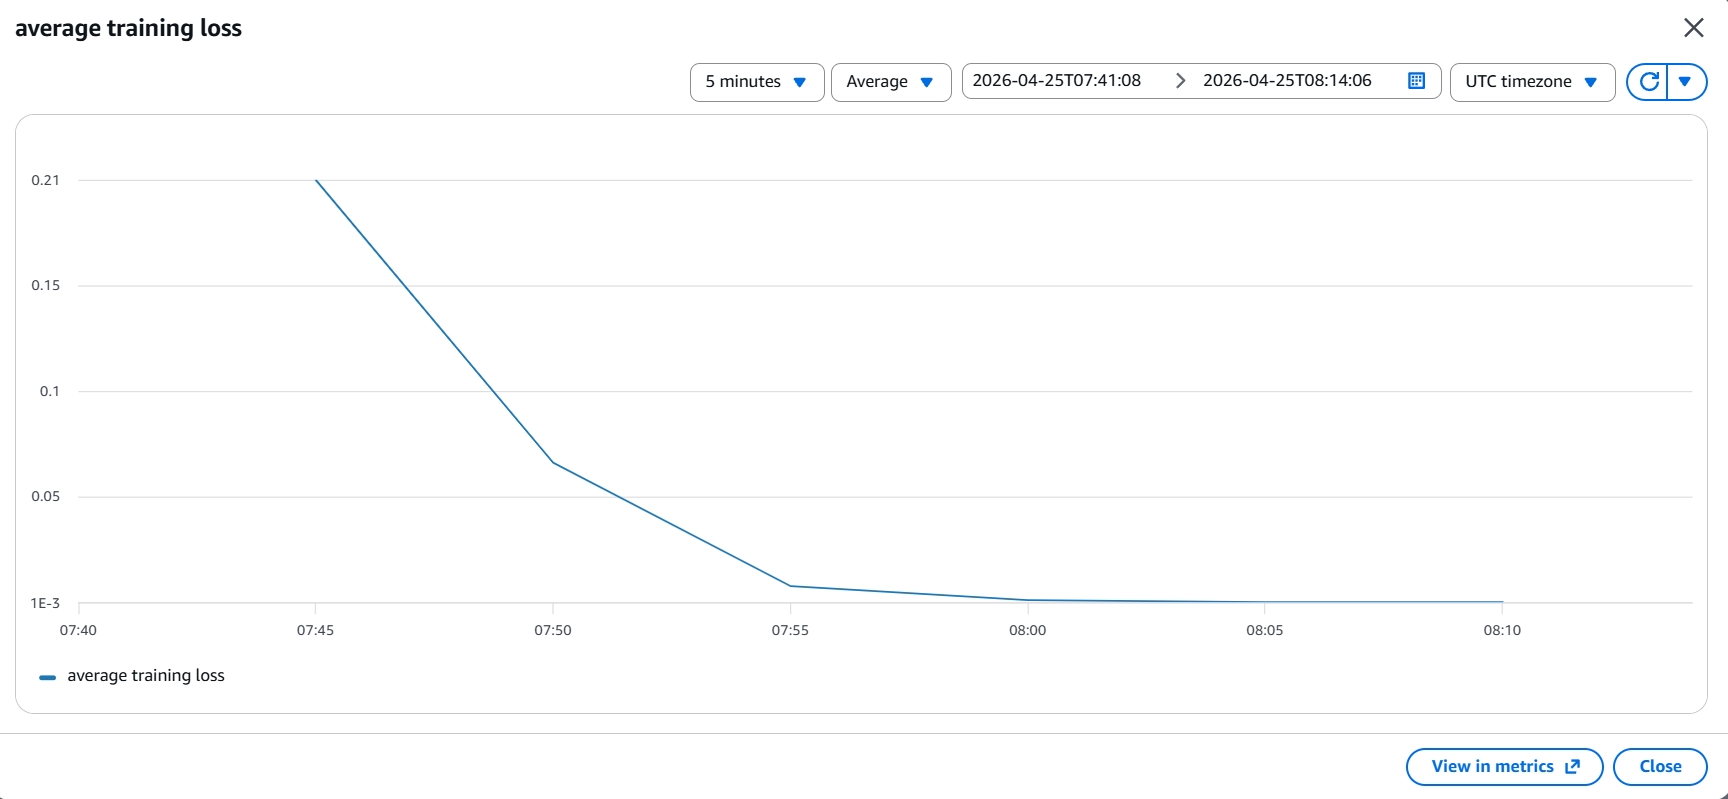

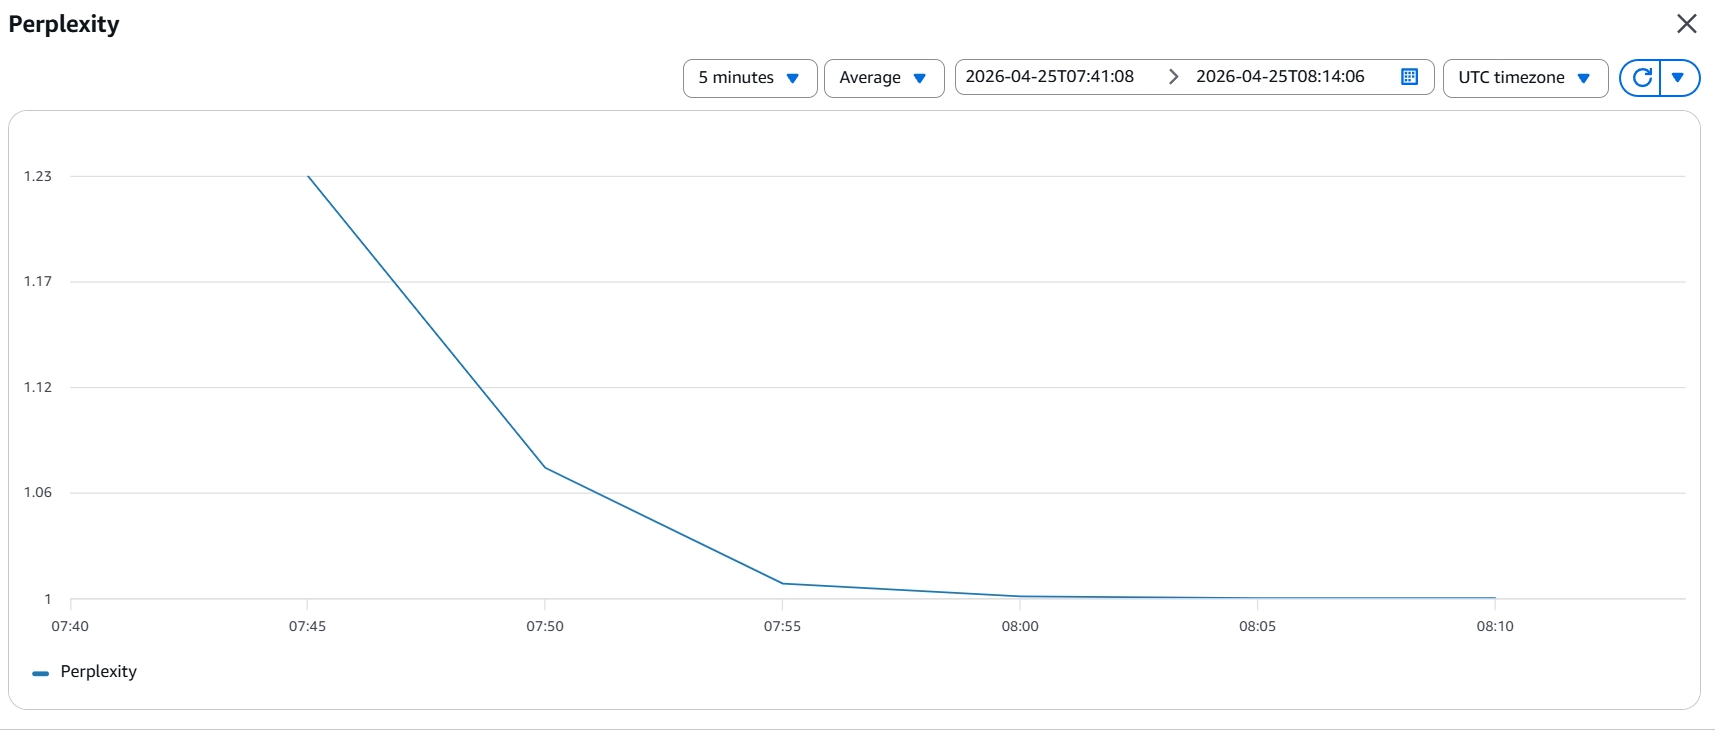

In [95]:
import os
CKPT_DIR = './model_ckpts'
os.makedirs(CKPT_DIR, exist_ok=True)

In [96]:
!aws s3 cp {est_brogpt.model_data} {CKPT_DIR}/

download: s3://sagemaker-us-east-1-191013407134/brogpt-train-2026-05-21-06-42-50-629/output/model.tar.gz to model_ckpts/model.tar.gz


In [97]:
!aws s3 ls {est_brogpt.model_data}

2026-05-21 08:01:17 1373776098 model.tar.gz


In [98]:
%cd {CKPT_DIR}

/home/ec2-user/SageMaker/CURRENTFOCUS/LLMS_transformers_WIP/LLMfromScratch/broGPT/model_ckpts


In [99]:
%pwd
!ls -ltrh

total 3.3G
-rw-r--r-- 1 ec2-user ec2-user  56M Feb 23  2025 ckpt_Epoch_100_Prplxty_1.0083447968191865.pt
-rw-rw-r-- 1 ec2-user ec2-user  51M Feb 23  2025 model_old.tar.gz
-rw-r--r-- 1 ec2-user ec2-user  56M Apr 25 06:31 ckpt_Epoch_50_Prplxty_1.010824581177966.pt
-rw-r--r-- 1 ec2-user ec2-user 351M Apr 25 07:18 ckpt_Epoch_40_Prplxty_1.0619401693860067.pt
-rw-r--r-- 1 ec2-user ec2-user 1.4G Apr 25 08:13 ckpt_Epoch_20_Prplxty_1.0012009449952726.pt
-rw-r--r-- 1 ec2-user ec2-user  56M May 21 05:18 ckpt_Epoch_100_Prplxty_1.0083859726932272.pt
-rw-rw-r-- 1 ec2-user ec2-user 1.3G May 21 08:01 model.tar.gz


In [100]:
!gunzip -dc model.tar.gz |tar xvf -

tar: Ignoring unknown extended header keyword `LIBARCHIVE.creationtime'
ckpt_Epoch_50_Prplxty_1.000727813408172.pt


In [101]:
!ls -ltrh

total 4.7G
-rw-r--r-- 1 ec2-user ec2-user  56M Feb 23  2025 ckpt_Epoch_100_Prplxty_1.0083447968191865.pt
-rw-rw-r-- 1 ec2-user ec2-user  51M Feb 23  2025 model_old.tar.gz
-rw-r--r-- 1 ec2-user ec2-user  56M Apr 25 06:31 ckpt_Epoch_50_Prplxty_1.010824581177966.pt
-rw-r--r-- 1 ec2-user ec2-user 351M Apr 25 07:18 ckpt_Epoch_40_Prplxty_1.0619401693860067.pt
-rw-r--r-- 1 ec2-user ec2-user 1.4G Apr 25 08:13 ckpt_Epoch_20_Prplxty_1.0012009449952726.pt
-rw-r--r-- 1 ec2-user ec2-user  56M May 21 05:18 ckpt_Epoch_100_Prplxty_1.0083859726932272.pt
-rw-r--r-- 1 ec2-user ec2-user 1.4G May 21 08:00 ckpt_Epoch_50_Prplxty_1.000727813408172.pt
-rw-rw-r-- 1 ec2-user ec2-user 1.3G May 21 08:01 model.tar.gz


In [102]:
tokenizer.vocab_size

50257

In [32]:
ckpt = "openai-community/gpt2"

In [33]:
model = AutoModelForCausalLM.from_pretrained(ckpt)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

In [34]:
model.to(device)

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [36]:
with open("./ckpt_Epoch_50_Prplxty_1.000727813408172.pt", 'rb') as f:
    checkpoint = torch.load(f, map_location=torch.device(device))
    print(f'checkpoint keys: {checkpoint.keys()}')
    model.load_state_dict(checkpoint['model_state_dict'])
    print("completed success")

checkpoint keys: dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'loss', 'device'])
completed success


In [37]:
!head -15 ./shakes_ds.txt 

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.



In [38]:
tokenizer = AutoTokenizer.from_pretrained(ckpt)

In [39]:
text = "First Citizen: "
input_ids = tokenizer.encode(text, return_tensors='pt')
input_ids, input_ids.shape

(tensor([[ 5962, 22307,    25,   220]]), torch.Size([1, 4]))

In [40]:
input_ids = input_ids.to(device)
model.to(device)

out = model(input_ids)
out=out.logits
out, out.shape

(tensor([[[-16.9014, -18.0946, -22.8603,  ..., -24.5920, -23.4182, -21.7039],
          [  7.9105,  -0.1253,  -2.7440,  ...,  -7.2965,  -0.8295,   2.4205],
          [ -2.7172,  -9.0908, -11.5981,  ..., -12.6887,  -6.8760,  -3.2829],
          [ 14.8870,  10.9061,   3.1571,  ...,   4.9270,  11.7273,   8.9567]]],
        grad_fn=<UnsafeViewBackward0>),
 torch.Size([1, 4, 50257]))

In [41]:
ids = torch.argmax(out, dim=-1)
gen_tok = ids[:,-1]
print(gen_tok)
dec = tokenizer.decode(gen_tok.squeeze().tolist())
print(dec)

tensor([2575])
urch


In [42]:
def generate_toks(model, tokenizer, device, prompt, num_toks):
    '''
    Greedy Decoding
    '''
    gen_list = []
    orig_prompt = prompt
    model.to(device)
    for i in range(num_toks):
        input_ids = tokenizer.encode(prompt, return_tensors='pt')
        input_ids = input_ids.to(device)
        out = model(input_ids)
        out = out.logits
        ids = torch.argmax(out, dim=-1)
        gen_tok = ids[:,-1]
        dec = tokenizer.decode(gen_tok.squeeze().tolist())
        gen_list.append(dec)
        prompt = prompt + " " + dec
    print(f"Original Prompt: {orig_prompt}")
    print(f"Original + Generated Prompt: {prompt}")
    return orig_prompt, prompt


In [43]:
#prompt = "First Citizen \n"
prompt = """Sir, he may live:
I saw him beat the surges under him,
And ride upon their backs; he trod the water,
Whose enmity he flung aside, and breasted"""
num_toks = 256
prompt, num_toks

('Sir, he may live:\nI saw him beat the surges under him,\nAnd ride upon their backs; he trod the water,\nWhose enmity he flung aside, and breasted',
 256)

In [44]:
generate_toks(model, tokenizer, device, prompt, num_toks)

Original Prompt: Sir, he may live:
I saw him beat the surges under him,
And ride upon their backs; he trod the water,
Whose enmity he flung aside, and breasted
Original + Generated Prompt: Sir, he may live:
I saw him beat the surges under him,
And ride upon their backs; he trod the water,
Whose enmity he flung aside, and breasted  them ;  Bore  the  shore .  MEN EN I US :  Peace ,  qu oth ,  peace !  Citizens :  sink , -- Soft , -- Soft , -- Soft , --  the  people ,  what  m  e re  a  grave .  MEN EN I US :  What , -- rop , --  or  something  p ite '  t ience ? --  O ,  I  would  thou  wast  the  man ,  the  beast !  O ,  thou  stern ,    thinking  no  other  kin !  O ,  thou  bloody  ,    thinking  i '  t  no  good  ' gain .  O ,  thou  meth ought ,  being  so ,  thou  dism ember 'd oubt ,  a  drum  ' tw ill - f ie ,  a  three - borough ,  a  drum  ' --  He b ade igned  these  words  by  him ,  who ,  for  this  hour  he --  S IC IN I  speak  of  him ,  who ,  who , --  D ost ent reat

('Sir, he may live:\nI saw him beat the surges under him,\nAnd ride upon their backs; he trod the water,\nWhose enmity he flung aside, and breasted',
 "Sir, he may live:\nI saw him beat the surges under him,\nAnd ride upon their backs; he trod the water,\nWhose enmity he flung aside, and breasted  them ;  Bore  the  shore .  MEN EN I US :  Peace ,  qu oth ,  peace !  Citizens :  sink , -- Soft , -- Soft , -- Soft , --  the  people ,  what  m  e re  a  grave .  MEN EN I US :  What , -- rop , --  or  something  p ite '  t ience ? --  O ,  I  would  thou  wast  the  man ,  the  beast !  O ,  thou  stern ,    thinking  no  other  kin !  O ,  thou  bloody  ,    thinking  i '  t  no  good  ' gain .  O ,  thou  meth ought ,  being  so ,  thou  dism ember 'd oubt ,  a  drum  ' tw ill - f ie ,  a  three - borough ,  a  drum  ' --  He b ade igned  these  words  by  him ,  who ,  for  this  hour  he --  S IC IN I  speak  of  him ,  who ,  who , --  D ost ent reat   ute   ute   ute   ute   ute   u

In [45]:
#Generate tokens using generate method

In [46]:
input_ids = tokenizer.encode(prompt, return_tensors='pt')
input_ids

tensor([[22788,    11,   339,   743,  2107,    25,   198,    40,  2497,   683,
          4405,   262, 47433,   739,   683,    11,   198,  1870,  6594,  2402,
           511, 12983,    26,   339,  4161,    67,   262,  1660,    11,   198,
          1199,   577,   551,    76,   414,   339, 45111,  7263,    11,   290,
          1449,  8992]])

In [47]:

gen_tokens = model.generate(
    input_ids,
    do_sample=True,
    temperature=0.8,
    max_length=num_toks,
)
gen_text = tokenizer.batch_decode(gen_tokens)[0]
print(gen_text)

[transformers] The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Sir, he may live:
I saw him beat the surges under him,
And ride upon their backs; he trod the water,
Whose enmity he flung aside, and breasted them; his noble hand Did will what he did spend and spent not that Which his triumphant father's hand had won; His hands were guilty of no kindred blood, But bloody with the enemies of his kin. O Margaret, I come, in kindness of your grace, To greet your highness and reverend father. QUEEN MARGARET: Your father, mighty Warwick! I come, in kind of life, To lay two fairisons in each hand: That both may point at once, though absent, Or never touch again. WARWICK: Forslow no longer, Warwick, but tell me again, 'Tis past doubt that Edward is your father. KING EDWARD IV: Now, brother Richard, Lord Hastings, and the rest, Yet that there is not a creature loves you more than me, That therefore you resign your highness; For how I think your father is affected To our behalf? GLOUCESTER: The better that Henry now doth promise you. KING EDWARD IV: Why, at o

In [48]:
gen_tokens = model.generate(
    input_ids,
    do_sample=True,
    temperature=1,
    max_length=num_toks,
)
gen_text = tokenizer.batch_decode(gen_tokens)[0]
print(gen_text)

[transformers] The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Sir, he may live:
I saw him beat the surges under him,
And ride upon their backs; he trod the water,
Whose enmity he flung aside, and breasted them; his bold head 'Bove the surge he kept, and oar'd Himself with his good arms in their quivering bosom. EDWARD: An if I may be, I will meet the king, or star, or what I list, And be a knight, take my knight to you. LADY ANNE: Good father, most gracious God Make thee prosperous in this royal presence! QUEEN MARGARET: And prosper thou, when thou shalt know whither. Good husband, God shield me from mischance! Hast thou meted him? CLARENCE: Ay, Clifford; and so, I hope, if thou wast he. QUEEN MARGARET: And so, I pray thee, help me to my closet. Oh, where are my dugs? CLARENCE: Above Antigonus, orcharded. QUEEN MARGARET: A good deed, father; but I fear I have done too much. Whose heart is that which takes it heavy to fit He


In [49]:
!tail -175 ./shakes_ds.txt 

Sir, he may live:
I saw him beat the surges under him,
And ride upon their backs; he trod the water,
Whose enmity he flung aside, and breasted
The surge most swoln that met him; his bold head
'Bove the contentious waves he kept, and oar'd
Himself with his good arms in lusty stroke
To the shore, that o'er his wave-worn basis bow'd,
As stooping to relieve him: I not doubt
He came alive to land.

ALONSO:
No, no, he's gone.

SEBASTIAN:
Sir, you may thank yourself for this great loss,
That would not bless our Europe with your daughter,
But rather lose her to an African;
Where she at least is banish'd from your eye,
Who hath cause to wet the grief on't.

ALONSO:
Prithee, peace.

SEBASTIAN:
You were kneel'd to and importuned otherwise
By all of us, and the fair soul herself
Weigh'd between loathness and obedience, at
Which end o' the beam should bow.We have lost your
son,
I fear, for ever: Milan and Naples have
More widows in them of this business' making
Than we bring men to comfort them:
Th

In [50]:
model.eval()
quantized_dynamic_model = torch.quantization.quantize_dynamic(
    model,
    {nn.Linear},
    dtype=torch.qint8
)
quantized_dynamic_model.eval()

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): DynamicQuantizedLinear(in_features=768, out_features=50257, dtype=torch.qint8, qscheme=torch.per_tensor_affine)

In [51]:
gen_tokens = quantized_dynamic_model.generate(
    input_ids,
    do_sample=True,
    temperature=1,
    max_length=num_toks,
)
gen_text = tokenizer.batch_decode(gen_tokens)[0]
print(gen_text)

[transformers] The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Sir, he may live:
I saw him beat the surges under him,
And ride upon their backs; he trod the water,
Whose enmity he flung aside, and breasted them; his face, So capital of his injury, he hung himself below the sea: I think, or in another sense, he did. PROSPERO: Who was it? Messenger: My master here carries a marvellous infection. First Servingman: Wine, wine, wine! What service is here! I think our master is come to order us how he may show his wounds: on his last known to me, he has them. COMINIUS: What is he that follows there, that brings him nothing? what he dreams of, That comes thence that he would weep. SICINIUS: Sir, you shall not be spoke with him. Messenger: They do entreat you. SICINIUS: They do entreat you. CORIOLANUS: I do not know what of all this. Sirrah, go to my house: Let me entreat you to wash your hands And fen with me. Proceed In justice, Perdita: hear this, and every one doth swear.


In [52]:
torch.save({
        'model_state_dict': quantized_dynamic_model.state_dict(),
        }, "quantized_gpt2")
!ls -ltrh

total 2.3G
drwxrwxr-x 3 ec2-user ec2-user 4.0K Feb 22  2025 scripts
-rw-rw-r-- 1 ec2-user ec2-user 1.9M Apr 25 07:35 BroGPT-GPT2TOK.ipynb
-rw-rw-r-- 1 ec2-user ec2-user  51M May 21 05:18 model.tar.gz
-rw-rw-r-- 1 ec2-user ec2-user 427K May 21 05:30 BroGPT-v1.ipynb
-rw-rw-r-- 1 ec2-user ec2-user 351M May 21 05:40 ckpt_Epoch_40_Prplxty_1.0619401693860067.pt
-rw-r--r-- 1 ec2-user ec2-user 1.4G May 21 08:00 ckpt_Epoch_50_Prplxty_1.000727813408172.pt
-rw-rw-r-- 1 ec2-user ec2-user 1.3M May 21 09:18 shakes_ds.csv
-rw-rw-r-- 1 ec2-user ec2-user 1.3M May 21 09:19 shakes_ds.txt
-rw-rw-r-- 1 ec2-user ec2-user 1.9M May 21 09:25 v1-BroGPT-GPT2Pretrained.ipynb
-rw-rw-r-- 1 ec2-user ec2-user 512M May 21 09:26 quantized_gpt2


In [55]:
gen_tokens = quantized_dynamic_model.generate(
    input_ids,
    do_sample=True,
    temperature=0.8,
    max_length=num_toks,
)
gen_text = tokenizer.batch_decode(gen_tokens)[0]
print(gen_text)

[transformers] The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Sir, he may live:
I saw him beat the surges under him,
And ride upon their backs; he trod the water,
Whose enmity he flung aside, and breasted them; his brave hand Hath had no violence in his life. ANGELO: Where is he, and what he stands for? ISABELLA: No matter where; of his nature, but to geld with beasts And other creeping creatures. LUCIO: Sir, bring forth your man. ANGELO: I am forth, alas! I am not well met. ISABELLA: O, no! I would cry a save. LUCIO: By your patience, I would thou wouldst. ANGELO: That I would cry a save. ISABELLA: Whate'er it be, I'll not plead for you. LUCIO: No, sir. ISABELLA: O, sir, I would thou wouldst cry a save. LUCIO: Save me not. I would thou wouldst, and nothing would thine. ANGELO: I would thou wouldst, and nothing would thine. LUCIO: Well, I come to what I would crave, or do. ISAB
